In [9]:
import numpy as np
import matplotlib.pyplot as plt

### Detector class

In [10]:
class Detector():
    def __init__(self, R: float, N: int, r: float, a: float):
        """
        Parameters
        ----------
        R : float
            Радиус детектора в метрах.
        N : int
            Количество фотоумножителей.
        r : float
            Радиус фотокатода в метрах.
        a : float
            Эффективность фотокатода.
        """
        self.R = R
        self.N = N
        self.r = r
        self.a = a
        self.rng = np.random.default_rng()

    def coord_cart(self, theta: float, phi: float) -> np.ndarray:
        return np.array([self.R * np.sin(theta)*np.cos(phi), self.R * np.sin(theta)*np.sin(phi), self.R*np.cos(theta)])

    def fill_detector(self):
        self.photo_multipliers = np.zeros((self.N, 3))
        S = 4 * self.R**2 * np.pi 
        delta_S = S / self.N 
        lin_size = delta_S**0.5 
        N_theta = np.pi * R / lin_size 
        delta_theta = np.pi / N_theta

        theta_floor = [int(np.floor(N_theta)), np.pi / np.floor(N_theta), delta_theta - np.pi / np.floor(N_theta)]
        theta_ceil = [int(np.ceil(N_theta)), np.pi / np.ceil(N_theta), delta_theta - np.pi / np.ceil(N_theta)]

        best_theta = min(theta_floor, theta_ceil, key=lambda x: abs(x[2]))
        N_theta, delta_theta = best_theta[0], best_theta[1]

        mid_thetas = np.array([delta_theta / 2 + delta_theta*i for i in range(0, N_theta)])
        n_phi = np.array([(np.pi * self.N)**0.5*np.sin(theta) for theta in mid_thetas])

        A = self.N / sum([np.sin(theta) for theta in mid_thetas])
        #n_phi = np.rint(np.array([A * np.sin(theta) for theta in mid_thetas])) #-> (3, 7, 10, 10, 7, 3)
        n_phi = np.array([2, 7, 11, 11, 7, 2])     

        phi_phases = np.zeros(N_theta)
        for i in range(N_theta):
            if i == 0:
                continue
            phi_phases[i] = np.pi / np.lcm(int(n_phi[i-1]), int(n_phi[i]))

        n = 0
        phase = 0
        for i in range(N_theta):
            if i < 3:
                phase += phi_phases[i]
            else:
                phase -= phi_phases[i]
            for j in range(int(n_phi[i])):
                self.photo_multipliers[n] = self.coord_cart(mid_thetas[i], 2*np.pi/n_phi[i] * j + phase)
                n += 1

    def in_chord(self, coord: np.ndarray) -> int:
        for k, photo_multiplier in enumerate(self.photo_multipliers):
            distance = np.linalg.norm(photo_multiplier-coord)
            if distance <= self.r:
                return k
        return -1

    def photo_electrons(self) -> int:
        return self.rng.poisson(lam=self.a)

    def register(self, coord: np.ndarray) -> int:
        id = self.in_chord(coord)
        if id < 0:
            return 0
        return self.photo_electrons()

    def register_many(self, hits: np.ndarray) -> int:
        diff = hits[:, None, :] - self.photo_multipliers[None, :, :]
        distances2 = np.sum(diff**2, axis=2)

        hit_mask = distances2 <= self.r**2

        photons_per_pmt = np.sum(hit_mask, axis=0)

        charge_per_pmt = self.rng.poisson(
            lam=self.a * photons_per_pmt
        )

        return np.sum(charge_per_pmt)
            

### Source class

In [11]:
class Source:
    def __init__(self, pos: np.ndarray):
        """
        Parameters
        ----------
        pos : np.array
            координаты источника
        """
        self.Y = 10000 
        self.pos = pos

    def sphere(self, R: float) -> np.ndarray: #взял метод из ROOT
        r2 = 1.0

        while r2 > 0.25:
            a = np.random.random() - 0.5
            b = np.random.random() - 0.5
            r2 = a**2 + b**2

        z = R * (-1.0 + 8.0 * r2)
        scale = 8.0 * R * np.sqrt(0.25 - r2)

        x = a * scale
        y = b * scale

        point = np.array([x, y, z])

        return point

    def generate_photons(self, E: float) -> np.ndarray:
        photon_number = int(E * self.Y)
        photons = np.zeros((photon_number, 3))
        for i in range(photon_number):
            photons[i] = self.sphere(1.0)
        return photons

    def generate_photons_vec(self, E: float) -> np.ndarray:
        photon_number = int(E * self.Y)

        phi = np.random.uniform(0, 2*np.pi, photon_number)
        cos_theta = np.random.uniform(-1, 1, photon_number)
        sin_theta = np.sqrt(1 - cos_theta**2)

        photons = np.column_stack((
            sin_theta * np.cos(phi),
            sin_theta * np.sin(phi),
            cos_theta
        ))

        return photons


### Задача 4

In [ ]:
def photon_propagation(pos: np.ndarray, direction: np.ndarray, R: float) -> np.ndarray:
    nr = np.dot(pos, direction)
    r = np.linalg.norm(pos)

    t = -nr + (nr**2 - (r**2 - R**2))**0.5
    hit = pos + direction * t
    return hit

def photon_propagation_vec(pos: np.ndarray, directions: np.ndarray, R: float) -> np.ndarray:
    nr = directions @ pos
    r2 = np.dot(pos, pos)

    t = -nr + np.sqrt(nr**2 - (r2 - R**2))

    hits = pos + directions * t[:, None]

    return hits

In [13]:
R = 2
N = 40
r = 0.1
a = 0.5

detector = Detector(R, N, r, a)
detector.fill_detector()
source_pos = np.array([0.5, 0.5, 0.5])
source = Source(source_pos)
photons = source.generate_photons(1.0)

### Очень долгий кусок кода вышел... выполняется симмуляция около 1.5 часов. 

In [15]:
'''N_event = 1000
energies = [0.2, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0]
positions = np.array(([0, 0, 0], [0, 0, 1]))
results = dict()

for p, position in enumerate(positions):
    for energy in energies[:1]:
        charges = np.zeros(N_event)
        for event in range(N_event):
            photons = source.generate_photons(energy)
            for photon in photons:
                hit = photon_propagation(position, photon, detector.R)
                charges[event] += detector.register(hit)
        results[(p, energy)] = charges'''

'N_event = 1000\nenergies = [0.2, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0]\npositions = np.array(([0, 0, 0], [0, 0, 1]))\nresults = dict()\n\nfor p, position in enumerate(positions):\n    for energy in energies[:1]:\n        charges = np.zeros(N_event)\n        for event in range(N_event):\n            photons = source.generate_photons(energy)\n            for photon in photons:\n                hit = photon_propagation(position, photon, detector.R)\n                charges[event] += detector.register(hit)\n        results[(p, energy)] = charges'

In [16]:
'''expected_charge = detector.a * source.Y * (detector.N * detector.r**2/(4*detector.R**2))
print(results.keys())
plt.hist(results[(1, 0.2)], bins=10)'''

'expected_charge = detector.a * source.Y * (detector.N * detector.r**2/(4*detector.R**2))\nprint(results.keys())\nplt.hist(results[(1, 0.2)], bins=10)'

#### В этот момент я вспомнил про третью лекцию и оптимизацию циклов через операции с массивами numpy
Добавил альтернативы для самых тяжелых методов:
- `generate_photons_vec` - генерирует равномерно все фотоны (тут я еще осознал что изотропное распределение по сфере можно получать через равномерное по $z$ и по $\varphi$).
- `photon_propagation_vec` - пропускает сразу все фотоны до детектора.
- `register_many` - расчитывает отклик детектора на все фотоны. Считает сколько фотонов попало в ФЭУ ($M$) и генерирует число фотоэлектроны по $\sim Pois(a\cdot M)$.
Время выполнения упало с 1.5 часов до 1.5 минут...

In [17]:
N_event = 1000
energies = [0.2, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0]
positions = np.array(([0, 0, 0], [0, 0, 1]))

results = {}

for p, position in enumerate(positions):
    for energy in energies:
        charges = np.zeros(N_event)

        for event in range(N_event):
            photons = source.generate_photons_vec(energy)
            hits = photon_propagation_vec(position, photons, detector.R)
            charges[event] = detector.register_many(hits)

        results[(p, energy)] = charges

mean 125.835
std 13.938930195678576


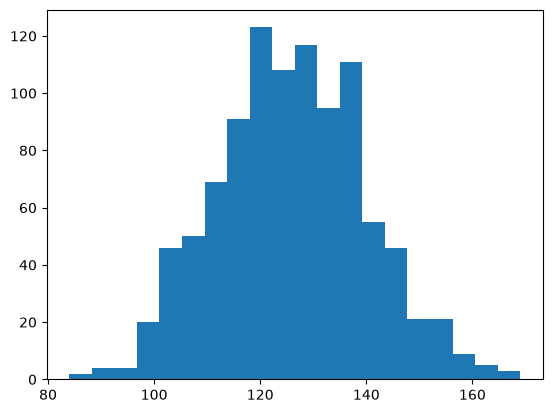

In [22]:
plt.hist(results[(0, 1.0)], bins=20)
print(f'mean {np.mean(results[(0, 1.0)])}')
print(f'std {np.std(results[(0, 1.0)])}')

In [28]:
stats = dict()

for key, val in results.items():
    mean = np.mean(val)
    std = np.std(val)
    rel_width = std/mean
    stats[key] = [mean, std, rel_width]

At center


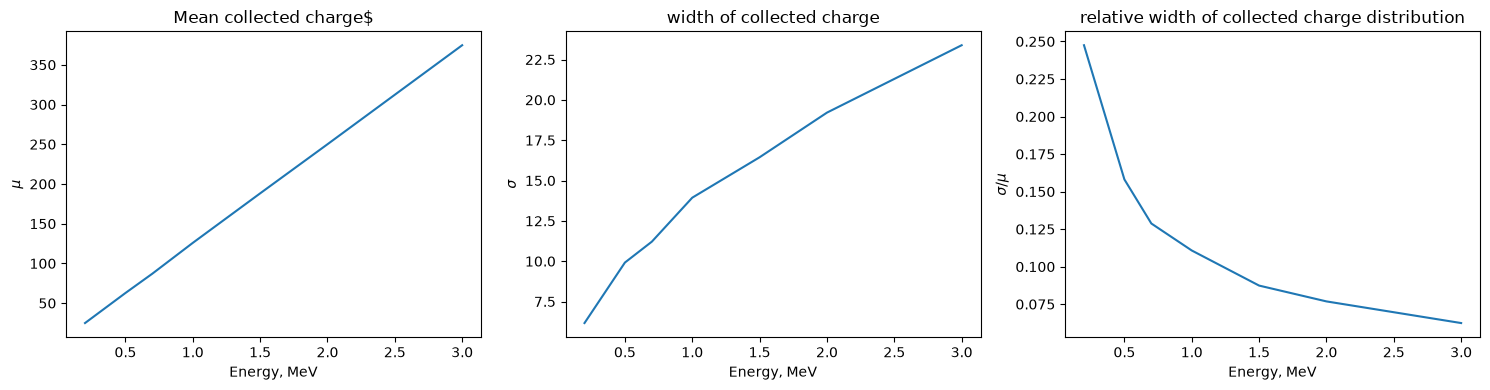

In [55]:
means = [stats[0, E][0] for E in energies]
stds = [stats[0, E][1] for E in energies]
rel_widths = [stats[0, E][2] for E in energies]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(energies, means)
axes[0].set_title(r"Mean collected charge$")
axes[0].set_xlabel(r"Energy, MeV")
axes[0].set_ylabel(r"$\mu$")

axes[1].plot(energies, stds)
axes[1].set_title(r"width of collected charge")
axes[1].set_xlabel(r"Energy, MeV")
axes[1].set_ylabel(r"$\sigma$")

axes[2].plot(energies, rel_widths)
axes[2].set_title(r"relative width of collected charge distribution")
axes[2].set_xlabel(r"Energy, MeV")
axes[2].set_ylabel(r"$\sigma$/$\mu$")
plt.tight_layout()
print("At center")
plt.show()

At z=1


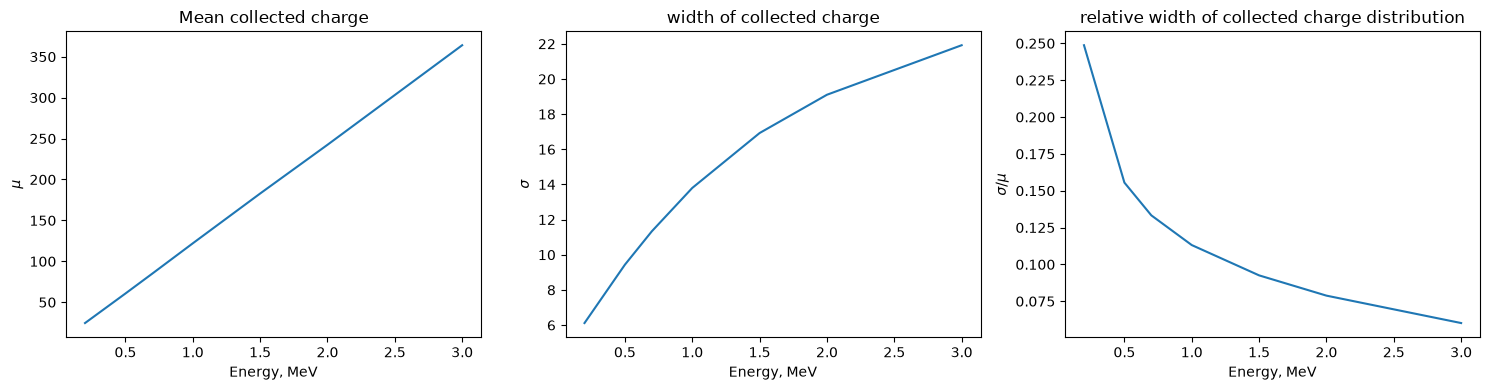

In [ ]:
means = [stats[1, E][0] for E in energies]
stds = [stats[1, E][1] for E in energies]
rel_widths = [stats[1, E][2] for E in energies]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(energies, means)
axes[0].set_title(r"Mean collected charge")
axes[0].set_xlabel(r"Energy, MeV")
axes[0].set_ylabel(r"$\mu$")

axes[1].plot(energies, stds)
axes[1].set_title(r"width of collected charge")
axes[1].set_xlabel(r"Energy, MeV")
axes[1].set_ylabel(r"$\sigma$")

axes[2].plot(energies, rel_widths)
axes[2].set_title(r"relative width of collected charge distribution")
axes[2].set_xlabel(r"Energy, MeV")
axes[2].set_ylabel(r"$\sigma$/$\mu$")
plt.tight_layout()
print("At z=1")
plt.show()


Относительная ширина распределений убывает с ростом энергии как $1/\sqrt{E}$

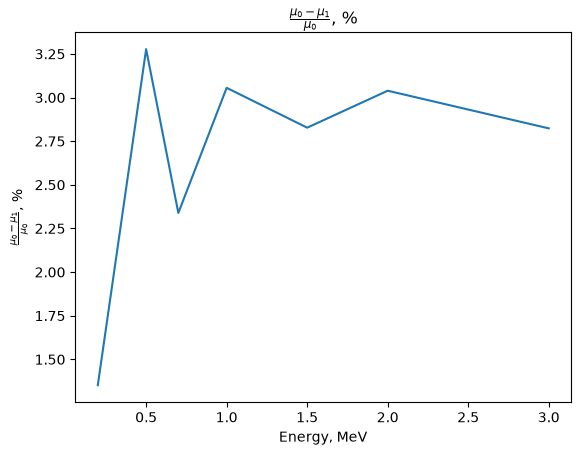

In [66]:
diff_means = [(stats[0, E][0] - stats[1, E][0]) / stats[0, E][0] * 100 for E in energies]
plt.plot(energies, diff_means)
plt.title(r"$\frac{\mu_0 - \mu_1}{\mu_0}$, %")
plt.xlabel(r"Energy, MeV")
plt.ylabel(r"$\frac{\mu_0 - \mu_1}{\mu_0}$, %")
plt.show()